In [1]:
# Cell 2: Imports & Configuration & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings

# 경고 무시 & 한글 폰트 설정
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 원본 데이터 로드
TRAIN_PATH = '../../data/train/train.csv' # 경로 확인
raw_train = pd.read_csv(TRAIN_PATH)

# 2. 'problems' 컬럼 파싱 (Nested JSON -> Flat Columns)
records = []
for idx, row in raw_train.iterrows():
    # problems 컬럼이 문자열 형태의 딕셔너리이므로 변환
    problems = literal_eval(row['problems'])
    
    record = {
        'id': row['id'],
        'paragraph': row['paragraph'],
        'question': problems['question'],
        'choices': problems['choices'], # 리스트 형태
        'answer': problems.get('answer', None),
        # question_plus는 csv 컬럼에 있거나 problems 안에 있을 수 있음 (둘 다 확인)
        'question_plus': row.get('question_plus') if pd.notna(row.get('question_plus')) else problems.get('question_plus', '')
    }
    records.append(record)

# 3. 전처리된 데이터프레임 생성
train = pd.DataFrame(records)

# NaN값 처리 (빈 문자열로)
train['question_plus'] = train['question_plus'].fillna('')

print(f"Data Shape: {train.shape}")
display(train.head(2))

Data Shape: (2031, 6)


,id,paragraph,question,choices,answer,question_plus
0,generation-for-nlp-425,"상소하여 아뢰기를 , “신이 좌참 찬 송준길이 올린 차자를 보았는데 , 상복(喪服)...",상소한 인물이 속한 붕당에 대한 설명으로 옳은 것만을 모두 고르면?,"[ㄱ, ㄴ, ㄱ, ㄷ, ㄴ, ㄹ, ㄷ, ㄹ]",2,
1,generation-for-nlp-426,"(가)은/는 의병계열과 애국계몽 운동 계열의 비밀결사가 모여 결성된 조직으로, 총사...",(가)에 대한 설명으로 옳지 않은 것은?,"[고려 문종 때에 남경(南京)으로 승격되었다., 종루(鐘樓), 이현, 칠패 등에서 ...",1,


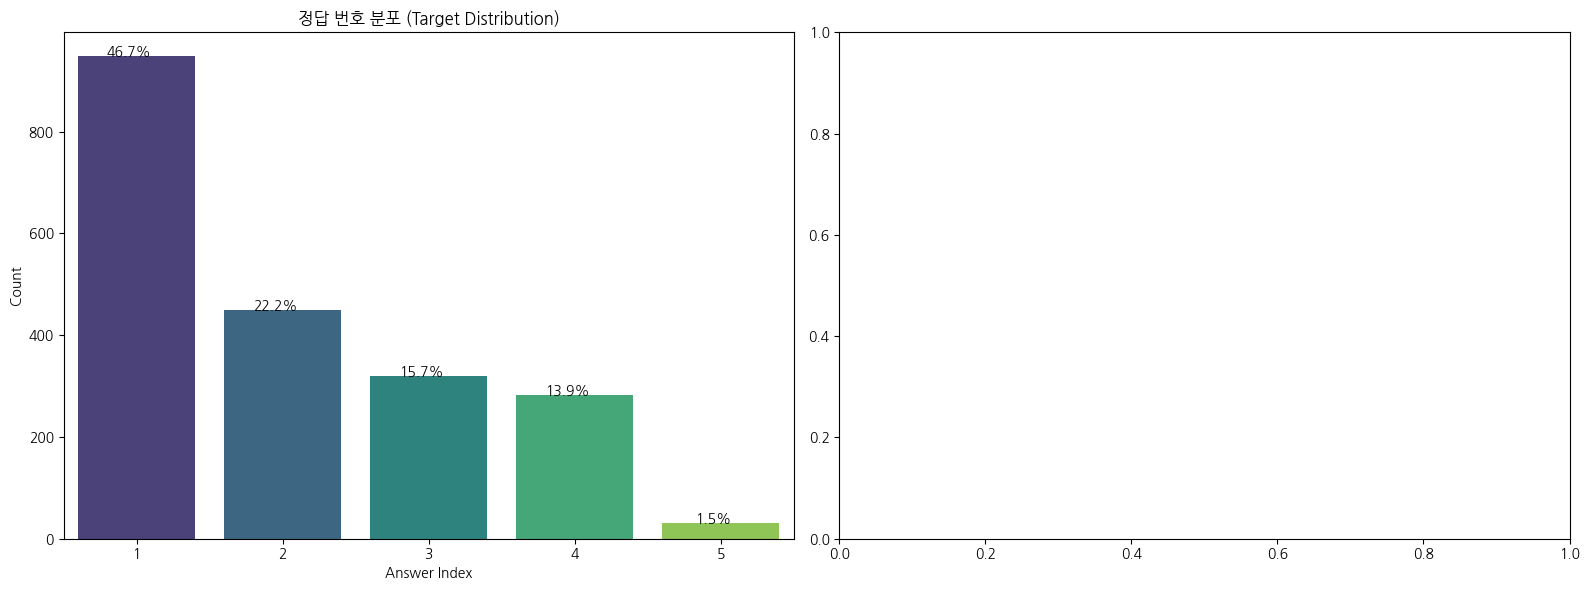

💡 Insight: 정답 분포가 불균형하다면, 학습 시 Loss에 Weight를 주거나 Stratified Split이 필수입니다.


In [2]:
# Cell 3: Answer & Category Distribution

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. 정답 분포 (Answer Distribution)
sns.countplot(x='answer', data=train, ax=ax[0], palette='viridis')
ax[0].set_title('정답 번호 분포 (Target Distribution)')
ax[0].set_xlabel('Answer Index')
ax[0].set_ylabel('Count')

# 비율 표시
total = len(train)
for p in ax[0].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax[0].annotate(percentage, (x, y), ha='center')

# 2. 문제 유형 분포 (Source Category)
# '세분류(사람)' 컬럼이 존재한다고 가정 (없으면 생성 필요)
if '세분류(사람)' in train.columns:
    dataset_counts = train['세분류(사람)'].value_counts()
    sns.barplot(x=dataset_counts.index, y=dataset_counts.values, ax=ax[1], palette='rocket')
    ax[1].set_title('문제 출처/유형 분포')
    ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Insight 도출
print("💡 Insight: 정답 분포가 불균형하다면, 학습 시 Loss에 Weight를 주거나 Stratified Split이 필수입니다.")

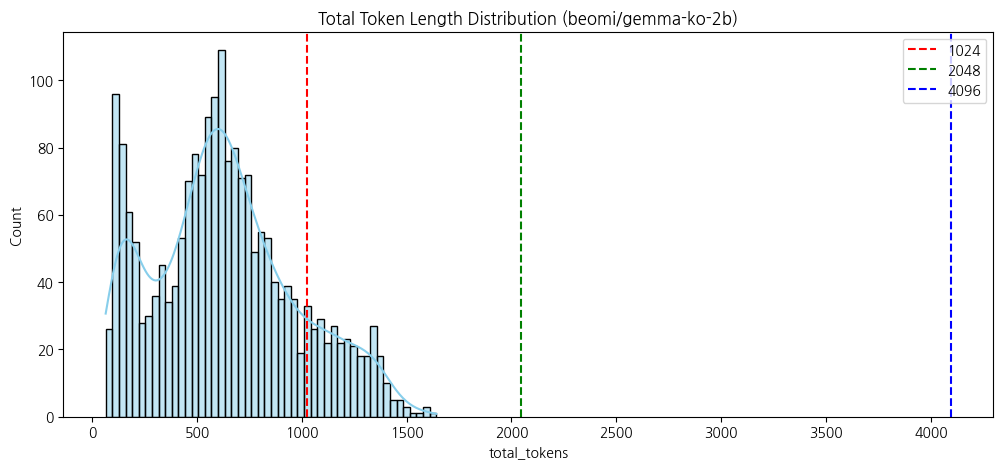

평균 길이: 634.00
Max 길이: 1642
95% 백분위수: 1276.00
99% 백분위수: 1413.70

💡 Action Item: 99% 백분위수 길이를 커버하는 max_seq_length를 Config에 설정하세요.


In [3]:
# Cell 4: Token Length Analysis
# 사용할 모델의 토크나이저 로드 (예: Qwen-2.5 또는 Llama-3)
MODEL_ID = "beomi/gemma-ko-2b" # 실제 사용할 모델로 변경 권장 (예: Qwen/Qwen2.5-14B-Instruct)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def get_token_len(row):
    # Prompt 형식에 맞춰 전체 길이 계산 (지문 + 질문 + 보기)
    # 실제 학습 프롬프트 포맷과 비슷하게 구성
    context = f"{row['paragraph']} {row.get('question_plus', '')}"
    choices = "\n".join([f"{i+1}. {c}" for i, c in enumerate(row['choices'])])
    full_text = f"지문:\n{context}\n\n질문:\n{row['question']}\n\n보기:\n{choices}"
    return len(tokenizer.encode(full_text))

# 길이 계산 (시간이 좀 걸릴 수 있음)
train['total_tokens'] = train.apply(get_token_len, axis=1)

# 시각화
plt.figure(figsize=(12, 5))
sns.histplot(train['total_tokens'], bins=50, kde=True, color='skyblue')
plt.axvline(x=1024, color='r', linestyle='--', label='1024')
plt.axvline(x=2048, color='g', linestyle='--', label='2048')
plt.axvline(x=4096, color='b', linestyle='--', label='4096')
plt.title(f'Total Token Length Distribution ({MODEL_ID})')
plt.legend()
plt.show()

# 통계 출력
print(f"평균 길이: {train['total_tokens'].mean():.2f}")
print(f"Max 길이: {train['total_tokens'].max()}")
print(f"95% 백분위수: {train['total_tokens'].quantile(0.95):.2f}")
print(f"99% 백분위수: {train['total_tokens'].quantile(0.99):.2f}")

print("\n💡 Action Item: 99% 백분위수 길이를 커버하는 max_seq_length를 Config에 설정하세요.")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Embedding Questions...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Running t-SNE...


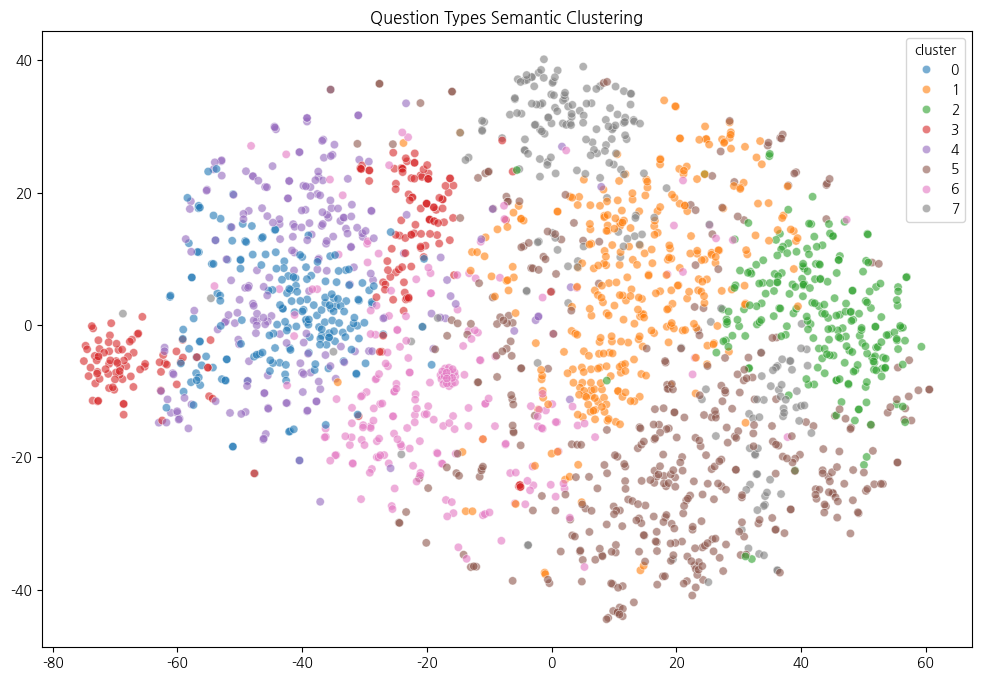


--- Cluster Interpretations ---

[Cluster 0] Sample Questions:
- 다음 중 말리 이슬람의 가장 가능성 있는 출처는?
- 다음 중 당시의 지적 사고에 관한 구절로 가장 잘 알 수 있는 것은 무엇입니까?
- 위에 인용된 언급은 다음 중 어떤 과정에서 비롯되었는가?

[Cluster 1] Sample Questions:
- '덕분에 챌린지' 캠페인의 주된 목적은 무엇인가?
- 닥터유디바이시즈의 오너인 사누시 우마르 박사가 제기한 소송의 주된 내용은 무엇인가?
- 지난해 한국의 자동차 수출량이 감소한 주된 이유는 무엇인가?

[Cluster 2] Sample Questions:
- 지난달 주택 거래량이 전년 동기 대비 얼마나 감소했는가?
- ‘4·1 부동산 종합대책’에 대한 여야의 이견 중 새누리당의 주장은 무엇인가?
- 서울 지하철 9호선의 혼잡도가 가장 높았던 시간대는 언제인가?

[Cluster 3] Sample Questions:
- 최근 미국에서 발생한 싱크홀 현상과 관련하여, 다음 중 싱크홀의 정의로 올바른 것은 무엇인가?
- 여기에 해당하지 않는 것은 무엇입니까?
- 다음 정책을 시행한 국왕의 재위 기간에 있었던 사실로 옳은 것은?

[Cluster 4] Sample Questions:
- 다음 중 위 헌법이 제정된 데에 가장 직접적인 책임이 있는 것은?
- 이 조약의 시발점은 무엇이었습니까?
- 다음 19세기 인물 중 위 법령에 묘사된 자유주의자들에게 반대할 가능성이 가장 적은 사람은 누구였습니까?

[Cluster 5] Sample Questions:
- 제주해군기지 공사 방해 혐의로 기소된 박모씨의 형량은 얼마인가?
- 파라다이스호텔 부산의 ‘고메 투고 박스’에서 제공되는 요리 중 중식당 ‘남풍’의 메뉴는 무엇인가?
- 전환손실을 1% 줄였을 때 대체할 수 있는 원자력발전소의 수는 몇 개인가?

[Cluster 6] Sample Questions:
- 어떤 유형의 실업입니까?
- 다음 행동중재전략(

In [4]:
# Cell 5: Semantic Clustering with Sentence-BERT

# 1. 임베딩 모델 로드 (한국어 성능 좋은 모델)
embedder = SentenceTransformer("intfloat/multilingual-e5-large")

# 2. 질문(Question)만 임베딩 (문제 의도는 질문에 가장 많이 담겨있음)
# 필요시 paragraph 요약본을 합칠 수도 있음
print("Embedding Questions...")
embeddings = embedder.encode(train['question'].tolist(), show_progress_bar=True)

# 3. K-Means Clustering
NUM_CLUSTERS = 8 # 적절히 조절
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42)
train['cluster'] = kmeans.fit_predict(embeddings)

# 4. 시각화 (t-SNE) - 2차원으로 차원 축소하여 시각화
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=train['cluster'], palette='tab10', alpha=0.6)
plt.title('Question Types Semantic Clustering')
plt.show()

# 5. 클러스터별 대표 질문 확인
print("\n--- Cluster Interpretations ---")
for i in range(NUM_CLUSTERS):
    print(f"\n[Cluster {i}] Sample Questions:")
    samples = train[train['cluster'] == i]['question'].sample(3).values
    for q in samples:
        print(f"- {q}")

In [ ]:
# Cell 6: Knowledge Necessity Classification (Router Training Data Generation)
# OpenAI API Key가 필요합니다.

import openai
from tqdm import tqdm

# client = openai.OpenAI(api_key="YOUR_KEY")

def classify_knowledge_type(row):
    """
    GPT-4o를 사용하여 문제 해결에 외부 지식이 필요한지 판단
    """
    prompt = f"""
    당신은 수능 문제 출제 위원입니다. 다음 문제를 보고, 이 문제를 풀기 위해 '지문 외의 외부 배경지식(역사적 사실, 과학 공식, 법률 조항 등)'이 필수적으로 필요한지 판단하세요.

    [기준]
    - External: 지문에 답의 근거가 없어서, 반드시 사전 지식이 있어야 풀 수 있음. (예: 한국사 연도 문제, 경제 공식 적용)
    - Internal: 지문을 꼼꼼히 읽으면 논리적으로 답을 도출할 수 있음. (예: 비문학 독해, 주제 찾기)

    [문제]
    지문: {row['paragraph'][:500]}...
    보기: {row.get('question_plus', '')}
    질문: {row['question']}

    응답 형식: JSON {{"reasoning": "이유...", "type": "External" or "Internal"}}
    """
    # 실제 API 호출 부분 (주석 처리됨)
    # response = client.chat.completions.create(...)
    # return response...
    return "External" # Dummy return

# 사용 예시:
# train['knowledge_type'] = train.apply(classify_knowledge_type, axis=1)
# print(train['knowledge_type'].value_counts())

print("💡 Action Item: 이 코드를 사용하여 Train 셋에 라벨링을 진행하세요. 이 데이터는 추후 Router 모델 학습에 사용됩니다.")

In [5]:
# Cell 7: Data Quality Check
import re

# 1. 보기(Choices) 개수가 4개 또는 5개가 아닌 경우
def check_choice_count(choices):
    return len(choices)

train['num_choices'] = train['choices'].apply(check_choice_count)
abnormal_choices = train[~train['num_choices'].isin([4, 5])]
print(f"이상한 보기 개수 발견: {len(abnormal_choices)} 건")
if len(abnormal_choices) > 0:
    display(abnormal_choices.head(2))

# 2. 정답 인덱스 범위 확인 (1~5 범위를 벗어나는지)
# choices 개수보다 큰 정답 번호가 있는지 확인
abnormal_answer = train[train['answer'] > train['num_choices']]
print(f"범위 밖 정답 발견: {len(abnormal_answer)} 건")

# 3. 특수문자/Broken Text 확인 (간단한 예시)
# 유니코드 깨짐이나 불필요한 태그가 있는지 확인
def has_broken_text(text):
    if pd.isna(text): return False
    # 예: HTML 태그나 이상한 기호
    return bool(re.search(r'<[^>]+>|[\uFFFD]', text))

train['is_broken'] = train['paragraph'].apply(has_broken_text)
print(f"손상된 텍스트 의심: {train['is_broken'].sum()} 건")

이상한 보기 개수 발견: 0 건
범위 밖 정답 발견: 0 건
손상된 텍스트 의심: 20 건
